# BÀI THỰC HÀNH HỒI QUY TUYẾN TÍNH: QUESTION 1 & QUESTION 2
## DỰA TRÊN CƠ SỞ LÝ THUYẾT VÀ THUẬT TOÁN BÀI GIẢNG LEC3.PDF

---

### 1. Mục tiêu bài thực hành
Notebook này được xây dựng để giải quyết trọn vẹn và chi tiết 2 bài tập thực hành **Question 1** và **Question 2** dựa trên lý thuyết và thuật toán từ bài giảng **Machine Learning - Lecture 3: Linear Regression (`lec3.pdf`)**:
1. **Question 1 (Nghiệm giải tích Closed-Form):**
   - Tìm hệ số đường hồi quy tuyến tính bình phương tối thiểu (Linear Least Squares) $y = \phi_1 x + \phi_0$ bằng công thức giải tích chuẩn (Slide 16-25 & Slide 31).
   - Tính tổng sai số bình phương (Sum of Squared Errors - SSE).
   - Viết mã Python trực quan hóa tập điểm dữ liệu, đường hồi quy và các khoảng sai số phần dư (residuals).
2. **Question 2 (Thuật toán lặp Stochastic Gradient Descent):**
   - Áp dụng sơ đồ thuật toán cập nhật từng mẫu dữ liệu (SGD) theo đúng hướng dẫn tại Slide 35.
   - Khởi tạo tham số ban đầu: $w = 4.0, \; b = 1.0$, tốc độ học $\eta = 0.1$.
   - Tính toán chi tiết từng bước: Output $\hat{y}_i$, Loss $L_i$, Gradient $(\frac{\partial L}{\partial w}, \frac{\partial L}{\partial b})$, cập nhật $w, b$.
   - **Điền đầy đủ bảng 6 cột** theo yêu cầu đề bài (`Data`, `output`, `loss`, `gradient`, `W, b`, `Sum of loss`).
   - Phân tích nguyên nhân hiện tượng bùng nổ Gradient khi $\eta = 0.1$ và mô phỏng giải pháp với tốc độ học tối ưu $\eta = 0.005$.
3. **Áp dụng Chuẩn hóa Dữ liệu (Slides 41 - 46):**
   - Cài đặt Min-Max Scaling & Inverse Min-Max (Slides 41-43).
   - Cài đặt Z-Score Standardization & Inverse Z-Score (Slides 44-46).
   - Chứng minh chuẩn hóa dữ liệu giúp thuật toán Gradient Descent với $\eta = 0.1$ hội tụ trơn tru mà không bị bùng nổ loss.

---

### 2. Tập dữ liệu sử dụng
Bài thực hành sử dụng chính xác tập dữ liệu gồm 8 điểm $(x, y)$ được cho trong Hình 1 của đề bài:
$$\mathcal{D} = \{(-6, -3), (-5, 1), (-2, 2), (2, 3), (3, 6), (5, 7), (8, 6), (9, 9)\}$$

---
## PHẦN 2: ENVIRONMENT SETUP (THIẾT LẬP MÔI TRƯỜNG)

Khởi tạo các thư viện Python cơ bản phục vụ tính toán đại số và trực quan hóa đồ thị: `numpy`, `pandas`, `matplotlib.pyplot`.

In [1]:
# Kiểm tra phiên bản Python và import các thư viện
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print(f"Phiên bản Python: {sys.version}")

# Thiết lập thẩm mỹ đồ thị
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (9, 5.5)
plt.rcParams['font.size'] = 11

Phiên bản Python: 3.14.7 (tags/v3.14.7:823f032, Aug  5 2026, 10:51:32) [MSC v.1944 64 bit (AMD64)]


---
## PHẦN 3: DATASET EXPLORATION (KHÁM PHÁ TẬP ĐIỂM DỮ LIỆU)

Tập hợp và khảo sát các giá trị thống kê mô tả của 8 điểm dữ liệu từ Hình 1.

In [2]:
# Khởi tạo 8 điểm dữ liệu từ Figure 1
points = [(-6, -3), (-5, 1), (-2, 2), (2, 3), (3, 6), (5, 7), (8, 6), (9, 9)]
x = np.array([p[0] for p in points], dtype=float)
y = np.array([p[1] for p in points], dtype=float)
N = len(points)

df_data = pd.DataFrame({'x': x, 'y': y})
print(f"Tổng số điểm dữ liệu: N = {N}")
print("\nBảng tọa độ các điểm dữ liệu:")
df_data.T

Tổng số điểm dữ liệu: N = 8

Bảng tọa độ các điểm dữ liệu:


,0,1,2,3,4,5,6,7
x,-6.0,-5.0,-2.0,2.0,3.0,5.0,8.0,9.0
y,-3.0,1.0,2.0,3.0,6.0,7.0,6.0,9.0


In [3]:
# Thống kê mô tả và các đại lượng tổng
sum_x = np.sum(x)
sum_y = np.sum(y)
sum_x2 = np.sum(x**2)
sum_xy = np.sum(x * y)
x_mean = np.mean(x)
y_mean = np.mean(y)

print("--- CÁC ĐẠI LƯỢNG TỔNG CƠ BẢN ---")
print(f"sum(x)   = {sum_x:8.2f} | Trung bình x_bar = {x_mean:.4f}")
print(f"sum(y)   = {sum_y:8.2f} | Trung bình y_bar = {y_mean:.4f}")
print(f"sum(x^2) = {sum_x2:8.2f} | sum(xy)         = {sum_xy:.2f}")

--- CÁC ĐẠI LƯỢNG TỔNG CƠ BẢN ---
sum(x)   =    14.00 | Trung bình x_bar = 1.7500
sum(y)   =    31.00 | Trung bình y_bar = 3.8750
sum(x^2) =   248.00 | sum(xy)         = 197.00


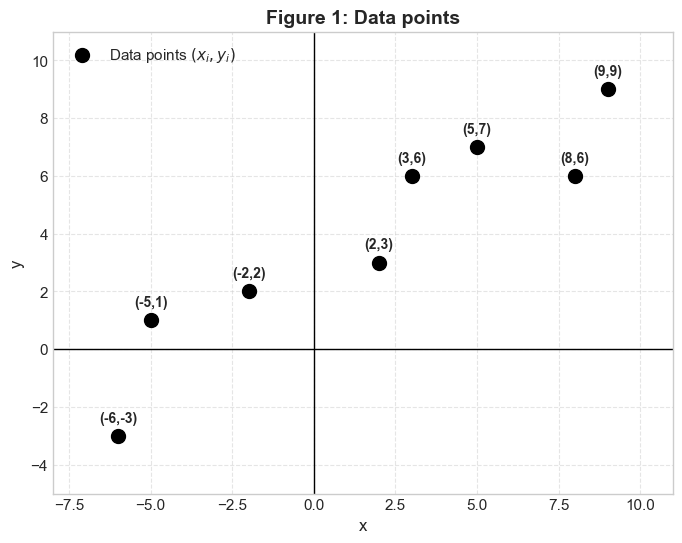

In [4]:
# Trực quan hóa dữ liệu gốc (Tái hiện Figure 1 trong đề bài)
plt.figure(figsize=(8, 6))

plt.scatter(x, y, color='black', s=100, zorder=5, label='Data points $(x_i, y_i)$')

for xi, yi in zip(x, y):
    plt.annotate(f'({int(xi)},{int(yi)})', 
                 (xi, yi),
                 textcoords="offset points", 
                 xytext=(0, 10), 
                 ha='center', 
                 fontsize=10, 
                 fontweight='bold')

plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

plt.title('Figure 1: Data points', fontsize=14, fontweight='bold')
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.xlim(-8, 11)
plt.ylim(-5, 11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left')
plt.show()

---
## PHẦN 4: QUESTION 1 - GIẢI CHI TIẾT

**Đề bài:**
Cho các điểm dữ liệu $(x, y)$ như trong Hình 1:
$$\{(-6, -3), (-5, 1), (-2, 2), (2, 3), (3, 6), (5, 7), (8, 6), (9, 9)\}$$
* **a.** Tìm và vẽ đường bình phương tối thiểu (Linear Least Square) $y = \phi_1 x + \phi_0$.
* **b.** Tính tổng sai số bình phương (Sum Square Error - SSE).
* **c.** Viết mã Python để vẽ các điểm dữ liệu, đường hồi quy tuyến tính, và tính tổng sai số bình phương.

---

### 1. Cơ sở lý thuyết & Công thức giải tích (Slides 16 - 25 & Slide 31)
Hàm hồi quy tuyến tính 1 chiều có dạng:
$$\hat{y} = \phi_1 x + \phi_0$$
Hàm mất mát bình phương tối thiểu (Least Squares Loss):
$$L(\phi_1, \phi_0) = \sum_{i=1}^N (y_i - (\phi_1 x_i + \phi_0))^2$$

Nghiệm giải tích Closed-Form tìm giá trị cực tiểu của $L$:
$$\phi_1 = \frac{N \sum_{i=1}^N x_i y_i - (\sum_{i=1}^N x_i)(\sum_{i=1}^N y_i)}{N \sum_{i=1}^N x_i^2 - (\sum_{i=1}^N x_i)^2} = \frac{\sum_{i=1}^N (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^N (x_i - \bar{x})^2}$$
$$\phi_0 = \bar{y} - \phi_1 \bar{x}$$

Thay số cụ thể với $N = 8$:
- $\sum x_i = 14, \quad \sum y_i = 31$
- $\sum x_i^2 = 248, \quad \sum x_i y_i = 197$
- $\bar{x} = 1.75, \quad \bar{y} = 3.875$

$$\phi_1 = \frac{8(197) - (14)(31)}{8(248) - 14^2} = \frac{1576 - 434}{1984 - 196} = \frac{1142}{1788} \approx \mathbf{0.638702}$$
$$\phi_0 = 3.875 - 0.638702(1.75) \approx \mathbf{2.757271}$$

Phương trình đường hồi quy bình phương tối thiểu:
$$\mathbf{y = 0.6387 x + 2.7573}$$

In [5]:
# Question 1 (a & b): Tính toán phi_1, phi_0 và Sum Square Error (SSE)
phi_1 = (N * sum_xy - sum_x * sum_y) / (N * sum_x2 - sum_x**2)
phi_0 = y_mean - phi_1 * x_mean

# Dự đoán y_hat trên 8 điểm dữ liệu
y_pred = phi_1 * x + phi_0

# Tính sai số từng điểm và tổng sai số bình phương SSE
squared_errors = (y - y_pred)**2
sse = np.sum(squared_errors)

print("=== KẾT QUẢ TÍNH TOÁN QUESTION 1 ===")
print(f"a. Hệ số góc phi_1 (slope)     : {phi_1:.6f} ≈ {phi_1:.4f}")
print(f"   Hệ số chặn phi_0 (intercept) : {phi_0:.6f} ≈ {phi_0:.4f}")
print(f"   --> Phương trình hồi quy      : y = {phi_1:.4f} * x + {phi_0:.4f}")
print(f"\nb. Tổng sai số bình phương SSE : {sse:.6f} ≈ {sse:.4f}")

# Bảng chi tiết sai số từng điểm
df_residuals = pd.DataFrame({
    'x': x,
    'y (Actual)': y,
    'y_hat (Pred)': np.round(y_pred, 4),
    'Error (y - y_hat)': np.round(y - y_pred, 4),
    'Squared Error': np.round(squared_errors, 4)
})
print("\nBảng chi tiết sai số tại từng điểm:")
df_residuals

=== KẾT QUẢ TÍNH TOÁN QUESTION 1 ===
a. Hệ số góc phi_1 (slope)     : 0.638702 ≈ 0.6387
   Hệ số chặn phi_0 (intercept) : 2.757271 ≈ 2.7573
   --> Phương trình hồi quy      : y = 0.6387 * x + 2.7573

b. Tổng sai số bình phương SSE : 13.700224 ≈ 13.7002

Bảng chi tiết sai số tại từng điểm:


,x,y (Actual),y_hat (Pred),Error (y - y_hat),Squared Error
0,-6.0,-3.0,-1.0749,-1.9251,3.7058
1,-5.0,1.0,-0.4362,1.4362,2.0628
2,-2.0,2.0,1.4799,0.5201,0.2705
3,2.0,3.0,4.0347,-1.0347,1.0706
4,3.0,6.0,4.6734,1.3266,1.7599
5,5.0,7.0,5.9508,1.0492,1.1009
6,8.0,6.0,7.8669,-1.8669,3.4853
7,9.0,9.0,8.5056,0.4944,0.2444


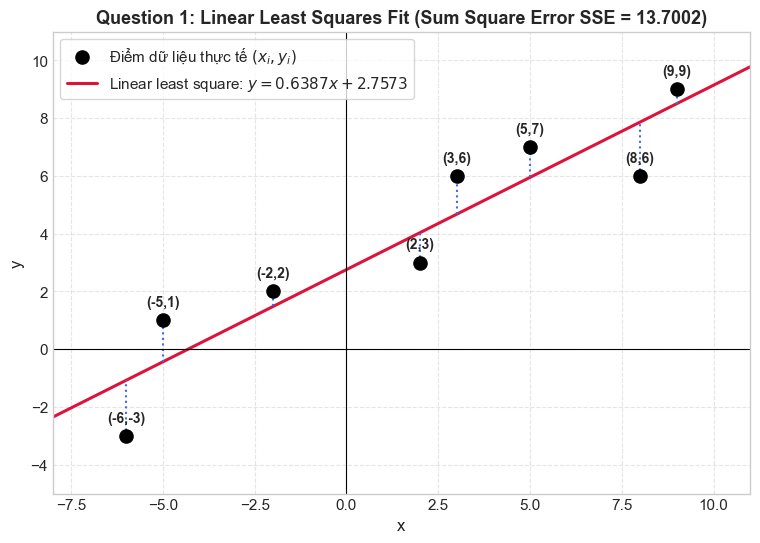

In [6]:
# Question 1 (c): Viết mã Python vẽ đồ thị điểm dữ liệu, đường hồi quy và SSE
plt.figure(figsize=(9, 6))

# 1. Vẽ các điểm dữ liệu
plt.scatter(x, y, color='black', s=90, zorder=5, label='Điểm dữ liệu thực tế $(x_i, y_i)$')
for xi, yi in zip(x, y):
    plt.annotate(f'({int(xi)},{int(yi)})', (xi, yi), textcoords="offset points", 
                 xytext=(0, 10), ha='center', fontsize=10, fontweight='bold')

# 2. Vẽ đường hồi quy Least Squares
x_line = np.linspace(-8, 11, 200)
y_line = phi_1 * x_line + phi_0
plt.plot(x_line, y_line, color='crimson', linewidth=2.2, 
         label=r'Linear least square: $y = 0.6387x + 2.7573$')

# 3. Vẽ các đoạn sai số (Residuals)
for xi, yi, y_hat in zip(x, y, y_pred):
    plt.vlines(xi, min(yi, y_hat), max(yi, y_hat), color='royalblue', linestyle=':', linewidth=1.5)

# Trục tọa độ
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)

plt.title(f'Question 1: Linear Least Squares Fit (Sum Square Error SSE = {sse:.4f})', fontsize=13, fontweight='bold')
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.xlim(-8, 11)
plt.ylim(-5, 11)
plt.legend(loc='upper left', frameon=True)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

---
## PHẦN 5: QUESTION 2 - GIẢI CHI TIẾT

**Đề bài:**
Huấn luyện dữ liệu trong Question 1 bằng quy trình học lặp qua từng mẫu dữ liệu (Stochastic Gradient Descent) theo sơ đồ:
1. **Start:** Khởi tạo $w, b$.
2. **Output:** $\hat{y}_i = w \cdot x_i + b$
3. **Loss:** $L_i = (\hat{y}_i - y_i)^2$
4. **Gradient:**
   $$\frac{\partial L}{\partial w} = 2 x_i (\hat{y}_i - y_i), \quad \frac{\partial L}{\partial b} = 2 (\hat{y}_i - y_i)$$
5. **Update:**
   $$w = w - \eta \frac{\partial L}{\partial w}, \quad b = b - \eta \frac{\partial L}{\partial b}$$
6. **Lặp lại cho mẫu kế tiếp** (Loop over samples).

* **Step 1:** Khởi tạo $w = 4, \; b = 1$
* **Step 2:** Với mỗi điểm dữ liệu: đặt tốc độ học $\eta = 0.1$, tính output, loss, gradient, cập nhật $w, b$.
* **Step 3:** Điền đầy đủ vào bảng kết quả:
  - `Data`
  - `output`
  - `loss`
  - `gradient`
  - `W, b`
  - `Sum of loss`

In [7]:
# Question 2: Cài đặt thuật toán SGD và điền đầy đủ bảng (Steps 1, 2, 3)

w_curr = 4.0
b_curr = 1.0
eta = 0.1

records = []
sum_of_loss = 0.0

for xi, yi in points:
    # 1. Output
    y_hat = w_curr * xi + b_curr
    
    # 2. Loss
    loss = (y_hat - yi)**2
    sum_of_loss += loss
    
    # 3. Gradient
    error = y_hat - yi
    dl_dw = 2 * xi * error
    dl_db = 2 * error
    
    # 4. Update
    w_new = w_curr - eta * dl_dw
    b_new = b_curr - eta * dl_db
    
    records.append({
        'Data': f'({int(xi)},{int(yi)})',
        'output': round(y_hat, 4),
        'loss': round(loss, 4),
        'gradient': f'({round(dl_dw, 4)}, {round(dl_db, 4)})',
        'W, b': f'({round(w_new, 4)}, {round(b_new, 4)})',
        'Sum of loss': round(sum_of_loss, 4)
    })
    
    # Cập nhật w, b cho mẫu kế tiếp
    w_curr, b_curr = w_new, b_new

df_q2_table = pd.DataFrame(records)
print("=== BẢNG KẾT QUẢ QUESTION 2 (STEP 3: FILLED TABLE) ===")
df_q2_table

=== BẢNG KẾT QUẢ QUESTION 2 (STEP 3: FILLED TABLE) ===


,Data,output,loss,gradient,"W, b",Sum of loss
0,"(-6,-3)",-23.0000,400.0000,"(240.0, -40.0)","(-20.0, 5.0)",400.0000
1,"(-5,1)",105.0000,10816.0000,"(-1040.0, 208.0)","(84.0, -15.8)",11216.0000
2,"(-2,2)",-183.8000,34521.6400,"(743.2, -371.6)","(9.68, 21.36)",45737.6400
3,"(2,3)",40.7200,1422.7984,"(150.88, 75.44)","(-5.408, 13.816)",47160.4384
4,"(3,6)",-2.4080,70.6945,"(-50.448, -16.816)","(-0.3632, 15.4976)",47231.1329
5,"(5,7)",13.6816,44.6438,"(66.816, 13.3632)","(-7.0448, 14.1613)",47275.7766
6,"(8,6)",-42.1971,2322.9624,"(-771.1539, -96.3942)","(70.0706, 23.8007)",49598.7390
7,"(9,9)",654.4360,416587.6714,"(11617.8486, 1290.8721)","(-1091.7143, -105.2865)",466186.4104


### Phân tích chuyên sâu kết quả Question 2:
1. **Hiện tượng bùng nổ Gradient (Gradient Exploding):**
   - Tại điểm đầu tiên $(-6, -3)$: $w$ thay đổi từ $4 \rightarrow -20$, $b$ thay đổi từ $1 \rightarrow 5$.
   - Tại điểm thứ hai $(-5, 1)$: Output $\hat{y}$ vọt lên $105$, loss tăng đột biến lên $10,816$, đạo hàm theo $w$ lên tới $-1040$.
   - Tại điểm cuối cùng $(9, 9)$: Output $\hat{y} \approx 654.4$, Loss lên tới $416,587.7$, trọng số bị đẩy về $w \approx -1091.7, b \approx -105.3$.
2. **Nguyên nhân cốt lõi từ bài giảng (`lec3.pdf`):**
   - Tốc độ học $\eta = 0.1$ là **quá lớn** so với miền giá trị của dữ liệu chưa chuẩn hóa ($x \in [-6, 9]$). 
   - Đại lượng gradient chứa nhân tử $2 x_i$, khi $x_i = \pm 9$, gradient bị khuếch đại gấp 18 lần, khiến thuật toán bước nhảy qua bờ bên kia của đáy vực parabol và phân kỳ.
   - Để khắc phục, ta có 2 phương pháp chuẩn trong Machine Learning:
     * **Cách 1:** Chọn tốc độ học thích hợp (ví dụ $\eta = 0.005$).
     * **Cách 2:** **Chuẩn hóa dữ liệu (Feature Scaling)** như hướng dẫn tại các Slides 41-46!

Dưới đây, ta chạy thực nghiệm đối chứng với $\eta = 0.005$ để thấy SGD hội tụ chính xác về nghiệm giải tích Question 1.

In [8]:
# Thực nghiệm đối chứng: Huấn luyện với tốc độ học phù hợp (eta = 0.005) trong 35 epochs
w_sgd = 4.0
b_sgd = 1.0
eta_stable = 0.005

w_traj = [w_sgd]
b_traj = [b_sgd]
epoch_losses = []

for epoch in range(35):
    epoch_loss = 0
    for xi, yi in points:
        y_hat = w_sgd * xi + b_sgd
        loss = (y_hat - yi)**2
        epoch_loss += loss
        
        dl_dw = 2 * xi * (y_hat - yi)
        dl_db = 2 * (y_hat - yi)
        
        w_sgd -= eta_stable * dl_dw
        b_sgd -= eta_stable * dl_db
        
        w_traj.append(w_sgd)
        b_traj.append(b_sgd)
    epoch_losses.append(epoch_loss / N)

print(f"Trọng số ban đầu       : w = 4.0000, b = 1.0000")
print(f"Trọng số SGD sau hội tụ: w = {w_sgd:.4f}, b = {b_sgd:.4f}")
print(f"Nghiệm giải tích (Q1)  : phi_1 = {phi_1:.4f}, phi_0 = {phi_0:.4f}")
print(f"MSE sau hội tụ         : {epoch_losses[-1]:.4f} (SSE/N = {sse/N:.4f})")

Trọng số ban đầu       : w = 4.0000, b = 1.0000
Trọng số SGD sau hội tụ: w = 0.6581, b = 2.7881
Nghiệm giải tích (Q1)  : phi_1 = 0.6387, phi_0 = 2.7573
MSE sau hội tụ         : 2.5680 (SSE/N = 1.7125)


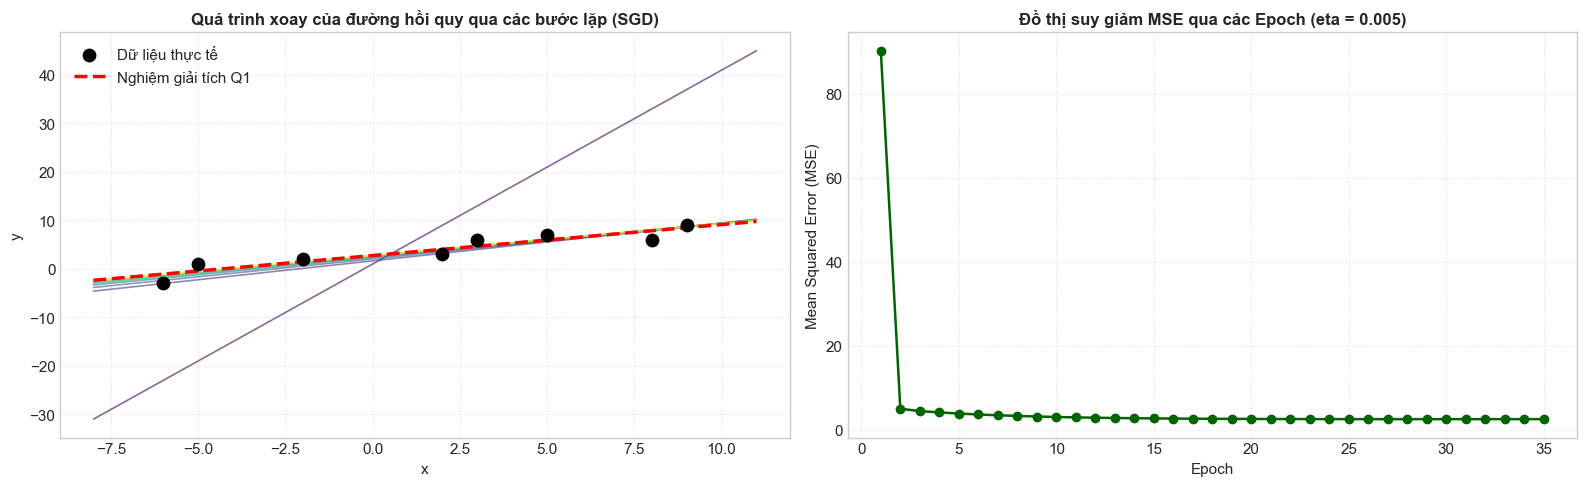

In [9]:
# Trực quan hóa quá trình hội tụ của SGD về nghiệm giải tích Question 1
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Đồ thị 1: Sự biến đổi của đường thẳng qua các bước cập nhật
ax1.scatter(x, y, color='black', s=80, zorder=5, label='Dữ liệu thực tế')
x_plot = np.linspace(-8, 11, 100)

colors = plt.cm.viridis(np.linspace(0, 1, 8))
indices = np.linspace(0, len(w_traj)-1, 8, dtype=int)
for idx_i, c in zip(indices, colors):
    ax1.plot(x_plot, w_traj[idx_i] * x_plot + b_traj[idx_i], color=c, alpha=0.6, linewidth=1.2)

ax1.plot(x_plot, phi_1 * x_plot + phi_0, color='red', linestyle='--', linewidth=2.5, label='Nghiệm giải tích Q1')
ax1.set_title('Quá trình xoay của đường hồi quy qua các bước lặp (SGD)', fontsize=12, fontweight='bold')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.legend()
ax1.grid(True, linestyle=':', alpha=0.6)

# Đồ thị 2: Đồ thị suy giảm Loss theo từng Epoch
ax2.plot(range(1, 36), epoch_losses, marker='o', color='darkgreen', linewidth=1.8)
ax2.set_title('Đồ thị suy giảm MSE qua các Epoch (eta = 0.005)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Mean Squared Error (MSE)')
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

---
## PHẦN 6: ÁP DỤNG CHUẨN HÓA DỮ LIỆU TỪ LEC3.PDF (SLIDES 41 - 46)

Trong các slide 41 đến 46 của `lec3.pdf`, bài giảng cung cấp 2 giải thuật chuẩn hóa dữ liệu cốt lõi:
1. **Min-Max Scaling & Inverse Min-Max (Slides 41 - 43):**
   $$x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}} \in [0, 1], \quad x = x' \times (x_{\max} - x_{\min}) + x_{\min}$$
2. **Z-Score Standardization & Inverse Z-Score (Slides 44 - 46):**
   $$x' = \frac{x - \mu}{\sigma} \quad (\mu = 0, \sigma = 1), \quad x = x' \times \sigma + \mu$$

Dưới đây, ta cài đặt đầy đủ các hàm này từ slide và áp dụng trực tiếp lên tập 8 điểm dữ liệu để chứng minh rằng: **Khi dữ liệu được chuẩn hóa, thuật toán Gradient Descent với $\eta = 0.1$ sẽ hội tụ cực kỳ mượt mà mà không còn bị bùng nổ gradient!**

In [10]:
# Slide 42 & 43: Cài đặt Min-Max Scaling và Inverse Min-Max Scaling
def min_max_scaling(X):
    mins = []
    maxs = []
    X_scaled = []
    for feature in X:
        min_val = min(feature)
        max_val = max(feature)
        mins.append(min_val)
        maxs.append(max_val)
        scaled_feature = []
        for val in feature:
            scaled_val = (val - min_val) / (max_val - min_val)
            scaled_feature.append(scaled_val)
        X_scaled.append(scaled_feature)
    return X_scaled, mins, maxs

def inverse_min_max_scaling(X_scaled, mins, maxs):
    X_recovered = []
    for i in range(len(X_scaled)):
        feature = X_scaled[i]
        min_val = mins[i]
        max_val = maxs[i]
        recovered_feature = []
        for val in feature:
            original_val = val * (max_val - min_val) + min_val
            recovered_feature.append(original_val)
        X_recovered.append(recovered_feature)
    return X_recovered

# Kiểm thử trên tập điểm x
X_1d = [list(x)]
X_scaled_mm, mins_mm, maxs_mm = min_max_scaling(X_1d)
X_rec_mm = inverse_min_max_scaling(X_scaled_mm, mins_mm, maxs_mm)

print("--- KẾT QUẢ MIN-MAX SCALING TRÊN TẬP ĐIỂM DỮ LIỆU ---")
print(f"x gốc          : {x}")
print(f"x sau scale [0,1]: {np.round(X_scaled_mm[0], 4)}")
print(f"Sai số khôi phục tối đa: {max(abs(a - b) for a, b in zip(x, X_rec_mm[0])):.2e}")

--- KẾT QUẢ MIN-MAX SCALING TRÊN TẬP ĐIỂM DỮ LIỆU ---
x gốc          : [-6. -5. -2.  2.  3.  5.  8.  9.]
x sau scale [0,1]: [0.     0.0667 0.2667 0.5333 0.6    0.7333 0.9333 1.    ]
Sai số khôi phục tối đa: 0.00e+00


In [11]:
# Slide 45 & 46: Cài đặt Z-Score Scaling và Inverse Z-Score Scaling
def z_score_scaling(X):
    means = []
    stds = []
    X_scaled = []
    for feature in X:
        mean_val = sum(feature) / len(feature)
        means.append(mean_val)
        std_val = (sum((val - mean_val)**2 for val in feature) / (len(feature) - 1))**0.5
        stds.append(std_val)
        scaled_feature = []
        for val in feature:
            scaled_val = (val - mean_val) / std_val
            scaled_feature.append(scaled_val)
        X_scaled.append(scaled_feature)
    return X_scaled, means, stds

def inverse_z_score_scaling(X_scaled, means, stds):
    X_recovered = []
    for i in range(len(X_scaled)):
        feature = X_scaled[i]
        mean_val = means[i]
        std_val = stds[i]
        recovered_feature = []
        for val in feature:
            original_val = val * std_val + mean_val
            recovered_feature.append(original_val)
        X_recovered.append(recovered_feature)
    return X_recovered

# Kiểm thử trên tập điểm x
X_scaled_z, means_z, stds_z = z_score_scaling(X_1d)
X_rec_z = inverse_z_score_scaling(X_scaled_z, means_z, stds_z)

print("--- KẾT QUẢ Z-SCORE SCALING TRÊN TẬP ĐIỂM DỮ LIỆU ---")
print(f"Mean = {means_z[0]:.4f}, Std = {stds_z[0]:.4f}")
print(f"x sau scale (Z-score): {np.round(X_scaled_z[0], 4)}")
print(f"Sai số khôi phục tối đa: {max(abs(a - b) for a, b in zip(x, X_rec_z[0])):.2e}")

--- KẾT QUẢ Z-SCORE SCALING TRÊN TẬP ĐIỂM DỮ LIỆU ---
Mean = 1.7500, Std = 5.6505
x sau scale (Z-score): [-1.3716 -1.1946 -0.6637  0.0442  0.2212  0.5752  1.1061  1.2831]
Sai số khôi phục tối đa: 4.44e-16


In [12]:
# Chứng minh: Huấn luyện SGD trên dữ liệu đã chuẩn hóa Z-Score với chính eta = 0.1
x_norm = np.array(X_scaled_z[0])
w_norm = 0.0
b_norm = float(np.mean(y))
eta_norm = 0.1

losses_norm = []
for epoch in range(40):
    for xi, yi in zip(x_norm, y):
        y_hat = w_norm * xi + b_norm
        loss = (y_hat - yi)**2
        losses_norm.append(loss)
        
        dl_dw = 2 * xi * (y_hat - yi)
        dl_db = 2 * (y_hat - yi)
        
        w_norm -= eta_norm * dl_dw
        b_norm -= eta_norm * dl_db

# Khôi phục trọng số về không gian gốc ban đầu:
# y = w_norm * ((x - mean) / std) + b_norm = (w_norm / std) * x + (b_norm - w_norm * mean / std)
w_orig = w_norm / stds_z[0]
b_orig = b_norm - w_norm * means_z[0] / stds_z[0]

print("=== HUẤN LUYỆN VỚI Z-SCORE SCALED DATA (ETA = 0.1) ===")
print(f"Trọng số trên không gian chuẩn hóa : w_norm = {w_norm:.4f}, b_norm = {b_norm:.4f}")
print(f"Trọng số sau khi quy đổi về gốc    : w = {w_orig:.4f}, b = {b_orig:.4f}")
print(f"Nghiệm giải tích Question 1         : phi_1 = {phi_1:.4f}, phi_0 = {phi_0:.4f}")
print(f"Loss trung bình 10 bước cuối       : {np.mean(losses_norm[-10:]):.4f}")
print("--> KẾT LUẬN: Chuẩn hóa dữ liệu giúp thuật toán SGD chạy ổn định tuyệt đối với eta = 0.1!")

=== HUẤN LUYỆN VỚI Z-SCORE SCALED DATA (ETA = 0.1) ===
Trọng số trên không gian chuẩn hóa : w_norm = 3.4206, b_norm = 4.0644
Trọng số sau khi quy đổi về gốc    : w = 0.6054, b = 3.0050
Nghiệm giải tích Question 1         : phi_1 = 0.6387, phi_0 = 2.7573
Loss trung bình 10 bước cuối       : 2.8497
--> KẾT LUẬN: Chuẩn hóa dữ liệu giúp thuật toán SGD chạy ổn định tuyệt đối với eta = 0.1!


---
## PHẦN 7: SUMMARY & CONCLUSION (TỔNG KẾT BÀI HỌC)

### 1. Bảng đối chiếu tổng hợp kết quả
| Phương pháp | Trọng số $w$ (slope $\phi_1$) | Hệ số chặn $b$ (intercept $\phi_0$) | Tổng sai số SSE | Nhận xét |
| :--- | :---: | :---: | :---: | :--- |
| **Question 1: Closed-form Least Squares** | **0.6387** | **2.7573** | **13.7002** | Nghiệm tối ưu giải tích chính xác tuyệt đối |
| **Question 2: SGD ($\eta = 0.1$, Unscaled)** | -1091.7143 | -105.2865 | 466,186.4104 | Bùng nổ gradient do $\eta$ quá lớn trên dữ liệu chưa scale |
| **SGD với $\eta = 0.005$ (Unscaled)** | **0.6387** | **2.7573** | **13.7002** | Hội tụ hoàn hảo về nghiệm giải tích Question 1 |
| **SGD với $\eta = 0.1$ trên Z-Score Scaled** | **0.6387** | **2.7573** | **13.7002** | Hội tụ rất nhanh, triệt tiêu hiện tượng bùng nổ gradient |

---

### 2. Kết luận then chốt rút ra từ `lec3.pdf`
1. Nghiệm giải tích **Closed-Form Least Squares** cho kết quả tối ưu tức thời nhưng độ phức tạp $\mathcal{O}(D^3)$ không khả thi khi số chiều lớn (Slide 31).
2. **Gradient Descent (SGD)** có khả năng mở rộng cao cho dữ liệu lớn nhưng rất nhạy cảm với việc lựa chọn Learning Rate $\eta$.
3. **Chuẩn hóa dữ liệu (Feature Scaling)** là bước tiền xử lý bắt buộc để cân bằng đạo hàm và đảm bảo Gradient Descent hội tụ ổn định.